In [7]:
import numpy as np
import MDAnalysis as mda
import os
import pandas as pd
import pickle
import matplotlib.pyplot as plt

from code_libraries.bilayer_operations import *
from code_libraries.acyl_chain_preprocessing import DOPC_op_H_av

In [8]:
start_frame , stop_frame = 0 , 2000

no_lipids = 300

In [9]:
dopc_pure_bilayer = Bilayer("dopc_pure"  , "sym" , start_frame , stop_frame)
dopc_pure_bilayer.cleave_leaflets()
dopc_pure_lower = dopc_pure_bilayer.lower_leaflet
dopc_pure_upper = dopc_pure_bilayer.upper_leaflet

dopc_pure = np.hstack([dopc_pure_lower , dopc_pure_upper])

In [10]:
dopc_60_bilayer = Bilayer("dopc_60"  , "sym" , start_frame , stop_frame)
dopc_60_bilayer.cleave_leaflets()
dopc_60_lower = dopc_60_bilayer.lower_leaflet[0]
dopc_60_upper = dopc_60_bilayer.upper_leaflet[0]

dopc_60 = np.hstack([dopc_60_lower , dopc_60_upper])

In [12]:
dopc_pure_ops_one_lipid_all_frames_sn1 = np.empty([no_lipids, stop_frame , 16])
dopc_60_ops_one_lipid_all_frames_sn1 = np.empty([no_lipids , stop_frame , 16])

dopc_pure_ops_one_lipid_all_frames_sn2 = np.empty([no_lipids , stop_frame , 16])
dopc_60_ops_one_lipid_all_frames_sn2 = np.empty([no_lipids , stop_frame , 16])


for l in range(no_lipids):

    for f in range(stop_frame):

        dopc_pure_ops_one_lipid_one_frame_sn1 = DOPC_op_H_av(dopc_pure[f , l] , "sn1")
        dopc_pure_ops_one_lipid_all_frames_sn1[l][f] = dopc_pure_ops_one_lipid_one_frame_sn1
        dopc_60_ops_one_lipid_one_frame_sn1 = DOPC_op_H_av(dopc_60[f , l] , "sn1")
        dopc_60_ops_one_lipid_all_frames_sn1[l][f] = dopc_60_ops_one_lipid_one_frame_sn1
        dopc_pure_ops_one_lipid_one_frame_sn2 = DOPC_op_H_av(dopc_pure[f , l] , "sn2")
        dopc_pure_ops_one_lipid_all_frames_sn2[l][f] = dopc_pure_ops_one_lipid_one_frame_sn2
        dopc_60_ops_one_lipid_one_frame_sn2 = DOPC_op_H_av(dopc_60[f , l] , "sn2")
        dopc_60_ops_one_lipid_all_frames_sn2[l][f] = dopc_60_ops_one_lipid_one_frame_sn2 

IndexError: index 250 is out of bounds for axis 0 with size 250

In [11]:
dopc_pure_ops_sn1 = np.mean(np.mean(dopc_pure_ops_one_lipid_all_frames_sn1 , axis = 0) ,axis = 0)
dopc_60_ops_sn1 = np.mean(np.mean(dopc_60_ops_one_lipid_all_frames_sn1 , axis =1) ,axis = 0)

dopc_pure_ops_sn2 = np.mean(np.mean(dopc_pure_ops_one_lipid_all_frames_sn2 , axis = 0) ,axis = 0)
dopc_60_ops_sn2 = np.mean(np.mean(dopc_60_ops_one_lipid_all_frames_sn2 , axis =1) ,axis = 0)


NameError: name 'dopc_pure_ops_sn1' is not defined

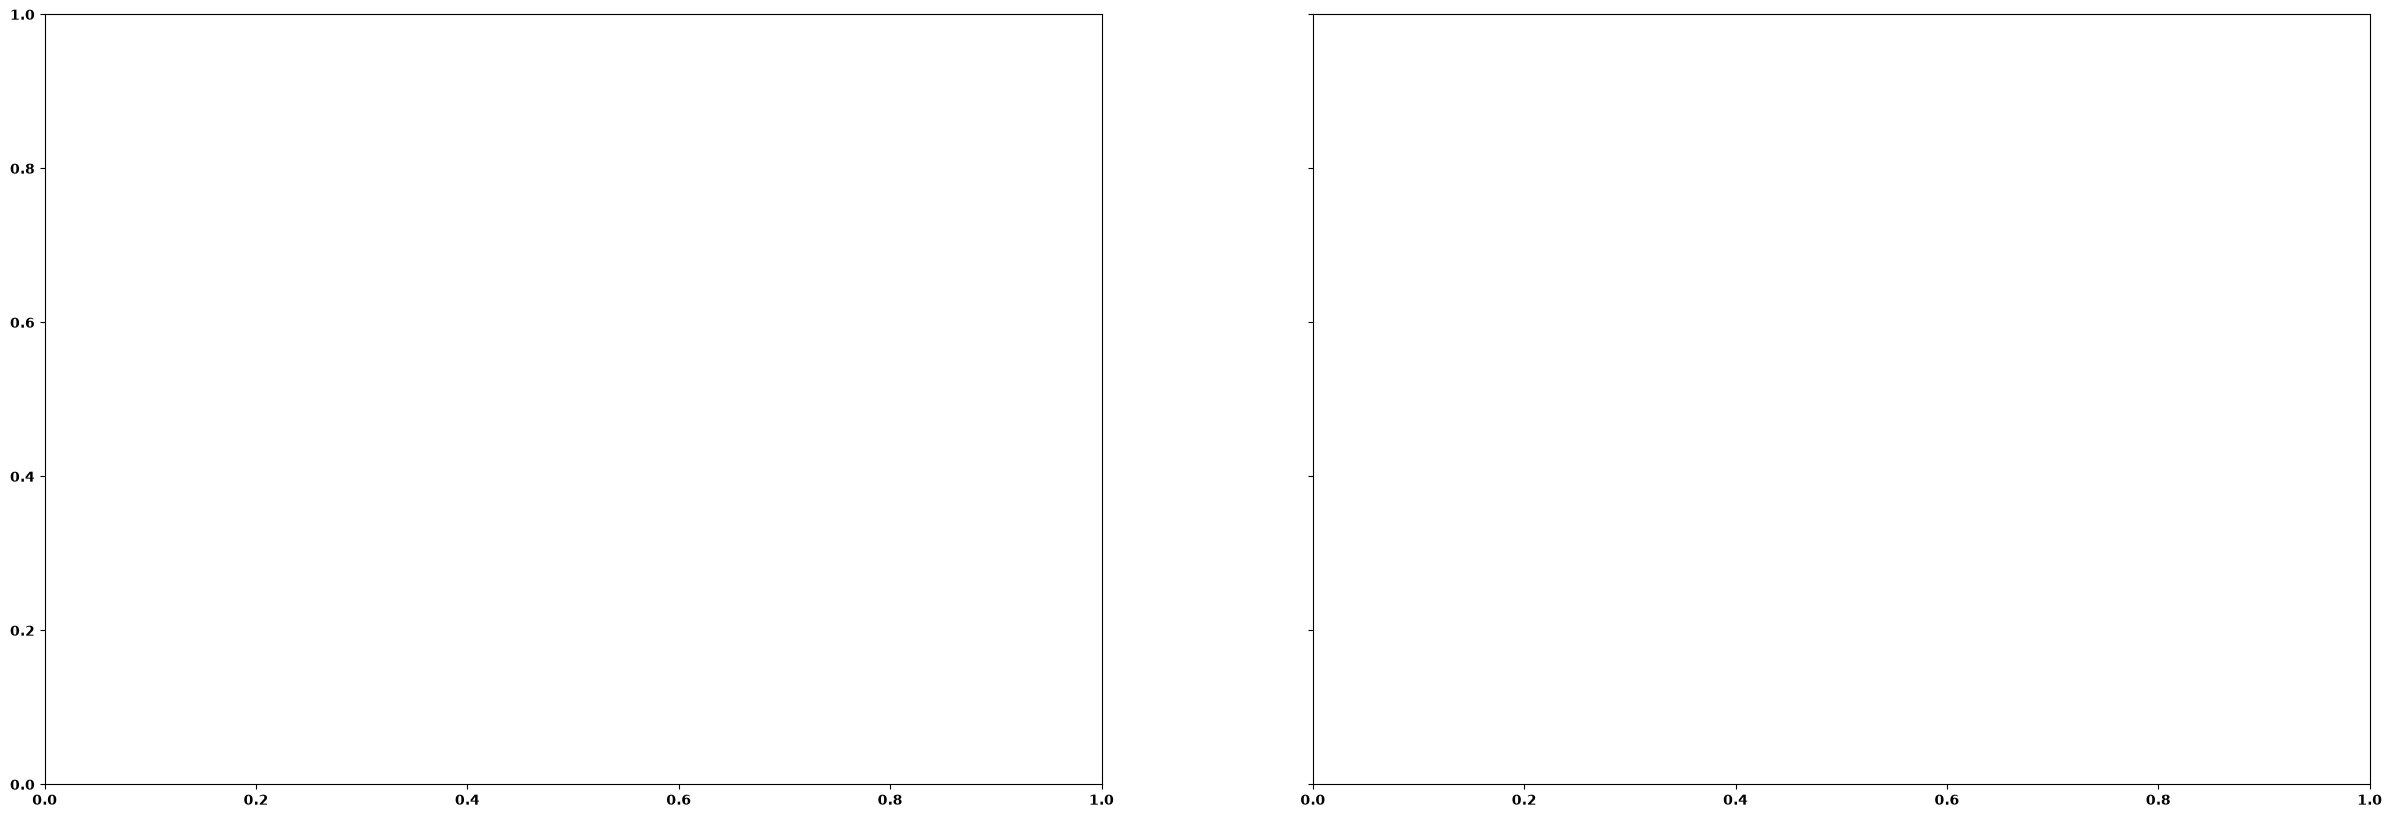

In [6]:
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
carbons = np.arange(1, 17)
fig, axes = plt.subplots(1, 2, figsize=(30, 10), sharey=True)
labels = ['a', 'b']
label_idx = 0
axes[0].plot(carbons, dopc_pure_ops_sn1, 'o-', color="green", label=r"$\mathbf{\chi_{C}}$ = 0", linewidth=4, markersize=10)
axes[0].plot(carbons, dopc_60_ops_sn1, 'o-', color="red", label=r"$\mathbf{\chi_{C}}$ = 0.40", linewidth=4, markersize=10)
axes[0].set_xlabel(r'Carbon Index', fontsize=35, fontweight='bold')
axes[0].set_ylabel(r'$\mathbf{S_{CD}}$', fontsize=35, fontweight='bold')
axes[0].set_title(r'$\mathbf{sn}$-1', fontsize=35, fontweight='bold')
axes[0].set_xticks([2, 4, 6, 8, 10, 12, 14, 16])
axes[0].tick_params(axis='both', which='major', labelsize=35, width=2.5, length=8, direction="inout")
# Make tick labels bold
for label in axes[0].get_xticklabels() + axes[0].get_yticklabels():
    label.set_fontweight('bold')
axes[0].text(0.5, 0.98, labels[label_idx], transform=axes[0].transAxes, 
                      fontsize=48, fontweight='bold', ha='center', va='top', color='darkblue')
legend0 = axes[0].legend(fontsize=25, prop={'weight':'bold', 'size': 30}, frameon=True, fancybox=True)
for line in legend0.get_lines():
    line.set_linewidth(5.0)
label_idx += 1
axes[1].plot(carbons, dopc_pure_ops_sn2, 'o-', color="green", label=r"$\mathbf{\chi_{C}}$ = 0", linewidth=4, markersize=10)
axes[1].plot(carbons, dopc_60_ops_sn2, 'o-', color="red", label=r"$\mathbf{\chi_{C}}$ = 0.40", linewidth=4, markersize=10)
axes[1].set_xlabel(r'Carbon Index', fontsize=35, fontweight='bold')
axes[1].set_title(r'$\mathbf{sn}$-2', fontsize=35, fontweight='bold')
axes[1].set_xticks([2, 4, 6, 8, 10, 12, 14, 16])
axes[1].tick_params(axis='both', which='major', labelsize=35, width=2.5, length=8, direction="inout")
# Make tick labels bold
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontweight('bold')
axes[1].text(0.5, 0.98, labels[label_idx], transform=axes[1].transAxes, 
                      fontsize=48, fontweight='bold', ha='center', va='top', color='darkblue')
legend1 = axes[1].legend(fontsize=25, prop={'weight':'bold', 'size': 30}, frameon=True, fancybox=True)
for line in legend1.get_lines():
    line.set_linewidth(5.0)
plt.tight_layout()
plt.show()